In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [23]:
from model import train_model, predict_demand, future_forecast

In [3]:
df = pd.read_csv("data/system_data.csv")
df.head()

,date,product_id,product_name,quantity_sold,price,stock_available
0,2023-01-01,101,Phone,5,20000,10
1,2023-01-02,102,Laptop,3,50000,8
2,2023-01-03,103,Shoes,7,3000,5
3,2023-01-04,101,Phone,6,20000,9
4,2023-01-05,102,Laptop,4,50000,7


In [4]:
STANDARD_COLUMNS = {
    "product_id": ["product_id", "p_id"],
    "product_name": ["product_name", "product"],
    "quantity_sold": ["quantity_sold", "qty", "quantity"],
    "price": ["price", "cost"],
    "stock_available": ["stock", "stock_available"]
}

def detect_columns(df):
    mapping = {}
    for std, variations in STANDARD_COLUMNS.items():
        for col in df.columns:
            if col.lower() in variations:
                mapping[std] = col
    return mapping

mapping = detect_columns(df)
mapping

{'product_id': 'product_id',
 'product_name': 'product_name',
 'quantity_sold': 'quantity_sold',
 'price': 'price',
 'stock_available': 'stock_available'}

In [5]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

In [6]:
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

In [7]:
X = df[["price", "month"]]
y = df["quantity_sold"]

rf = RandomForestRegressor()
lr = LinearRegression()

rf.fit(X, y)
lr.fit(X, y)

LinearRegression()

In [8]:
df["rf_pred"] = rf.predict(X)
df["lr_pred"] = lr.predict(X)

# Auto-select best model
if r2_score(y, df["rf_pred"]) > r2_score(y, df["lr_pred"]):
    df["predicted_sales"] = df["rf_pred"]
    best_model = "RandomForest"
else:
    df["predicted_sales"] = df["lr_pred"]
    best_model = "LinearRegression"

print("Best Model:", best_model)

Best Model: LinearRegression


In [9]:
df["revenue"] = df["price"] * df["predicted_sales"]
df.head()

,date,product_id,product_name,quantity_sold,price,stock_available,month,day,rf_pred,lr_pred,predicted_sales,revenue
0,2023-01-01,101,Phone,5,20000,10,1,1,5.628667,5.620289,5.620289,112405.770126
1,2023-01-02,102,Laptop,3,50000,8,1,2,3.616167,3.456491,3.456491,172824.569567
2,2023-01-03,103,Shoes,7,3000,5,1,3,6.496167,6.846440,6.846440,20539.320614
3,2023-01-04,101,Phone,6,20000,9,1,4,5.628667,5.620289,5.620289,112405.770126
4,2023-01-05,102,Laptop,4,50000,7,1,5,3.616167,3.456491,3.456491,172824.569567


In [10]:
r2 = r2_score(y, df["predicted_sales"])
mae = mean_absolute_error(y, df["predicted_sales"])

print("R2 Score:", r2)
print("MAE:", mae)

R2 Score: 0.8943694741740345
MAE: 0.4307119590507213


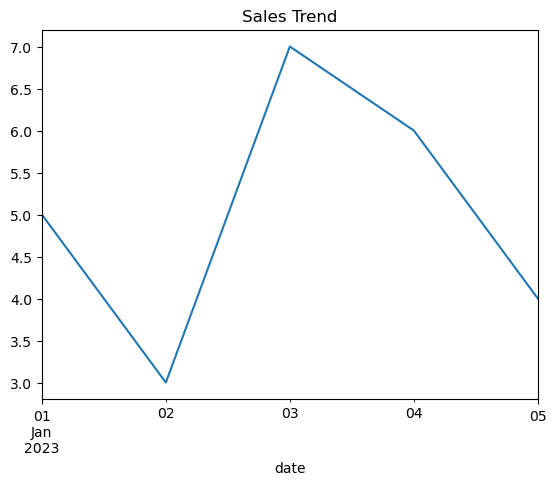

In [11]:
df.groupby("date")["quantity_sold"].sum().plot()
plt.title("Sales Trend")
plt.show()

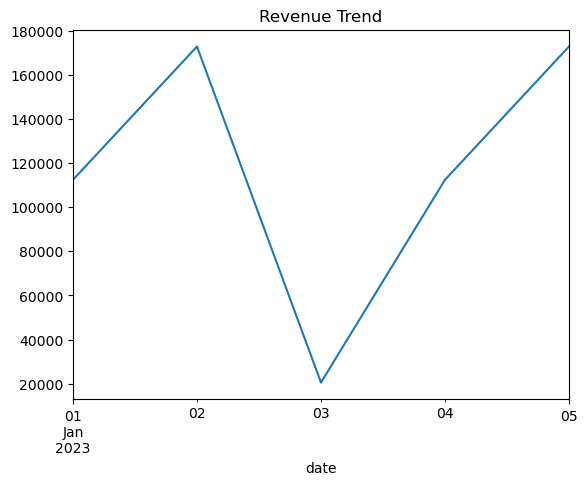

In [12]:
df.groupby("date")["revenue"].sum().plot()
plt.title("Revenue Trend")
plt.show()

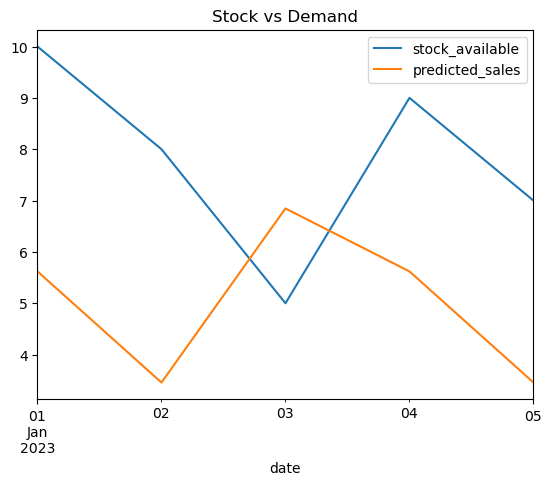

In [13]:
df.plot(x="date", y=["stock_available", "predicted_sales"])
plt.title("Stock vs Demand")
plt.show()

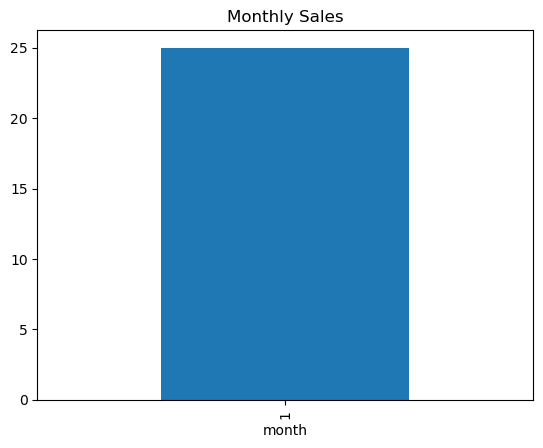

In [14]:
df.groupby("month")["quantity_sold"].sum().plot(kind="bar")
plt.title("Monthly Sales")
plt.show()

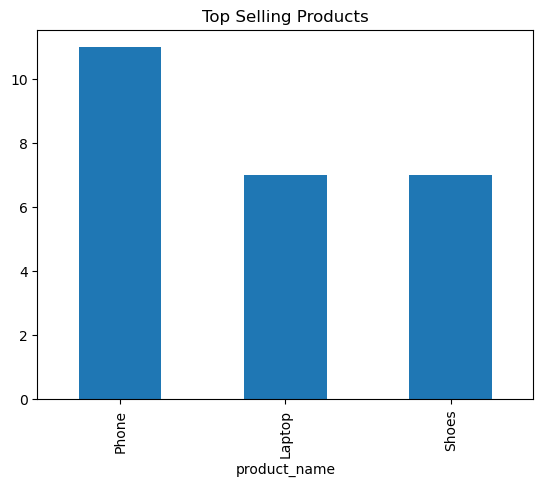

In [15]:
top_products = df.groupby("product_name")["quantity_sold"].sum().sort_values(ascending=False)

top_products.plot(kind="bar")
plt.title("Top Selling Products")
plt.show()

In [17]:
def stock_analysis(df):
    status = []

    for i, row in df.iterrows():
        if row["predicted_sales"] > row["stock_available"]:
            status.append("Stockout Risk")
        elif row["stock_available"] > row["predicted_sales"] * 2:
            status.append("Overstock")
        else:
            status.append("Balanced")

    df["stock_status"] = status
    return df

df = stock_analysis(df)
df.head()

,date,product_id,product_name,quantity_sold,price,stock_available,month,day,rf_pred,lr_pred,predicted_sales,revenue,stock_status
0,2023-01-01,101,Phone,5,20000,10,1,1,5.628667,5.620289,5.620289,112405.770126,Balanced
1,2023-01-02,102,Laptop,3,50000,8,1,2,3.616167,3.456491,3.456491,172824.569567,Overstock
2,2023-01-03,103,Shoes,7,3000,5,1,3,6.496167,6.846440,6.846440,20539.320614,Stockout Risk
3,2023-01-04,101,Phone,6,20000,9,1,4,5.628667,5.620289,5.620289,112405.770126,Balanced
4,2023-01-05,102,Laptop,4,50000,7,1,5,3.616167,3.456491,3.456491,172824.569567,Overstock


In [18]:
def recommendation(df):
    rec = []

    for i, row in df.iterrows():
        if row["stock_status"] == "Stockout Risk":
            rec.append("Reorder")
        elif row["stock_status"] == "Overstock":
            rec.append("Discount")
        else:
            rec.append("No Action")

    df["recommendation"] = rec
    return df

df = recommendation(df)
df.head()

,date,product_id,product_name,quantity_sold,price,stock_available,month,day,rf_pred,lr_pred,predicted_sales,revenue,stock_status,recommendation
0,2023-01-01,101,Phone,5,20000,10,1,1,5.628667,5.620289,5.620289,112405.770126,Balanced,No Action
1,2023-01-02,102,Laptop,3,50000,8,1,2,3.616167,3.456491,3.456491,172824.569567,Overstock,Discount
2,2023-01-03,103,Shoes,7,3000,5,1,3,6.496167,6.846440,6.846440,20539.320614,Stockout Risk,Reorder
3,2023-01-04,101,Phone,6,20000,9,1,4,5.628667,5.620289,5.620289,112405.770126,Balanced,No Action
4,2023-01-05,102,Laptop,4,50000,7,1,5,3.616167,3.456491,3.456491,172824.569567,Overstock,Discount


In [19]:
if "customer_id" in df.columns:
    df["customer_id"].value_counts().head().plot(kind="bar")
    plt.title("Top Customers")
    plt.show()

In [20]:
df

,date,product_id,product_name,quantity_sold,price,stock_available,month,day,rf_pred,lr_pred,predicted_sales,revenue,stock_status,recommendation
0,2023-01-01,101,Phone,5,20000,10,1,1,5.628667,5.620289,5.620289,112405.770126,Balanced,No Action
1,2023-01-02,102,Laptop,3,50000,8,1,2,3.616167,3.456491,3.456491,172824.569567,Overstock,Discount
2,2023-01-03,103,Shoes,7,3000,5,1,3,6.496167,6.846440,6.846440,20539.320614,Stockout Risk,Reorder
3,2023-01-04,101,Phone,6,20000,9,1,4,5.628667,5.620289,5.620289,112405.770126,Balanced,No Action
4,2023-01-05,102,Laptop,4,50000,7,1,5,3.616167,3.456491,3.456491,172824.569567,Overstock,Discount


In [24]:
# FUTURE FORECAST DEMO

# Train model
models = train_model(df)

# Get best model
df, best_model, model_obj = predict_demand(df, models)

# Predict future (example: 7 days)
future = future_forecast(df, model_obj, days=7)

future



,date,month,price,predicted_sales
0,2023-01-06,1,28600.0,5.0
1,2023-01-07,1,28600.0,5.0
2,2023-01-08,1,28600.0,5.0
3,2023-01-09,1,28600.0,5.0
4,2023-01-10,1,28600.0,5.0
5,2023-01-11,1,28600.0,5.0
6,2023-01-12,1,28600.0,5.0
